In [1141]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

In [1142]:
data = yf.download("^NSEI", start="2023-10-24", end="2026-3-20", interval="1d")

print(data.head())  
print(data.tail())  
data.columns = data.columns.get_level_values(0)

C:\Users\dell\AppData\Local\Temp\ipykernel_11928\3470193282.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("^NSEI", start="2023-10-24", end="2026-3-20", interval="1d")
[*********************100%***********************]  1 of 1 completed

Price              Close          High           Low          Open  Volume
Ticker             ^NSEI         ^NSEI         ^NSEI         ^NSEI   ^NSEI
Date                                                                      
2023-10-25  19122.150391  19347.300781  19074.150391  19286.449219  225300
2023-10-26  18857.250000  19041.699219  18837.849609  19027.250000  300400
2023-10-27  19047.250000  19076.150391  18926.650391  18928.750000  205200
2023-10-30  19140.900391  19158.500000  18940.000000  19053.400391  180100
2023-10-31  19079.599609  19233.699219  19056.449219  19232.949219  206000
Price              Close          High           Low          Open  Volume
Ticker             ^NSEI         ^NSEI         ^NSEI         ^NSEI   ^NSEI
Date                                                                      
2026-03-13  23151.099609  23492.400391  23112.000000  23462.500000  519800
2026-03-16  23408.800781  23502.000000  22955.250000  23116.099609  540300
2026-03-17  23581.150391 

In [ ]:

# Features
data['change'] = data['Close'] - data['Open']
data['status'] = data['change'].apply(lambda x: "BULL" if x >= 0 else "BEAR") 
data['Prev_Close'] = data['Close'].shift(1)


# remove NaN
data = data.dropna()


status
BEAR    312
BULL    280
Name: count, dtype: int64


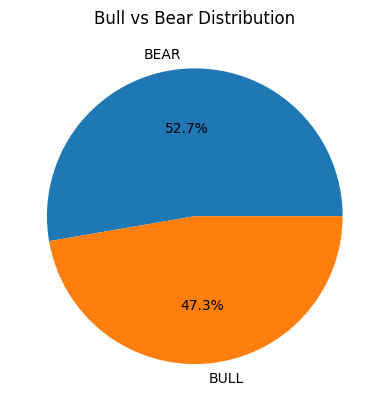

In [ ]:
# Pie chart
counts = data['status'].value_counts()
print(counts)
plt.figure()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("Bull vs Bear Distribution")
plt.show()

In [ ]:
# Features
X = data[['Open','Prev_Close']]
y = data['status']

# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [ ]:
# scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)   

In [1147]:

# model
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [1148]:
# predict
y_pred = model.predict(X_test)

In [1149]:
# X_open = np.array([23110.55]).reshape(-1, 1)
# X_open_scale = scaler.transform(X_open)
# y_pred = model.predict(X_open_scale)

# testResult = pd.DataFrame({"open":X_open.reshape(-1,), "status":y_pred})
# testResult.head(len(testResult))

In [1150]:
# accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"accuracy : {accuracy*100:.2f}%")

accuracy : 61.24%


[[66 37]
 [32 43]]


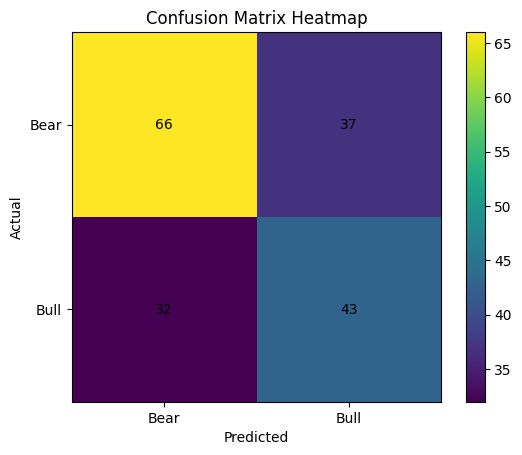

In [1151]:
cm = np.array(confusion_matrix(y_test, y_pred))
print(cm)
plt.figure()
plt.imshow(cm)

plt.xticks([0,1], ["Bear", "Bull"])
plt.yticks([0,1], ["Bear", "Bull"])

# show numbers inside
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")

plt.colorbar()
plt.show()